![Py4Eng](../logo.png)

# Transfer Learning
## Yoav Ram

In this session we will understand:
- why a 20-million-parameter network cannot be trained from scratch on 6,000 images
- how to reuse a network trained on one task as a *feature extractor* for another
- the two standard protocols: a **linear probe** on frozen features, and a **full fine-tune**
- how to fine-tune without destroying the pretrained weights: frozen batch-norm, a low learning rate, warmup, cosine decay, and label smoothing
- how to measure the gap between the two protocols honestly, including run-to-run variance

## Why transfer learning?

Everything we have trained so far started from random weights. That works for MNIST, which has 60,000 training images of 10 very simple classes. It stops working quickly.

Consider the task in this session: classify a photograph of a bird into one of **200 species**. The dataset has 5,994 training images — about 30 images per species. The network we are going to use, `EfficientNetV2S`, has roughly 20 million parameters. Fitting 20 million parameters to 6,000 examples is hopeless: the model can memorize the training set exactly and learn nothing that generalizes.

The classic measurement of exactly this: training the same architecture from scratch on this dataset gives **10.9%** accuracy, while starting from ImageNet-pretrained weights gives **57.0%** ([Branson et al. 2014](https://arxiv.org/abs/1406.2952)). Same architecture, same data, same number of parameters — the only difference is where the weights started.

The idea of *transfer learning* is that the early layers of an image classifier learn things that are not specific to its training task: edges, textures, colour gradients, then parts and shapes. Those are useful for almost any vision task. So instead of learning them again from 6,000 images, we take them from a model that learned them from 1.2 million ImageNet images, and only learn the part that is specific to our task.

There are two standard ways to do this, and this session implements both:

1. **Linear probe.** Freeze the pretrained network entirely and use it as a fixed function that maps an image to a vector of features. Train only a softmax regression on top of those features. This is the softmax model from Day 2, applied to features instead of pixels.
2. **Fine-tune.** Let some of the pretrained weights change too, carefully, with a small learning rate.

The first is cheap and hard to get wrong. The second is more expensive and can *destroy* the pretrained features if done carelessly. Which one wins is not as obvious as it sounds — we will come back to that in the discussion.

In [39]:
%matplotlib inline
import matplotlib.pyplot as plt
import pickle
import tarfile
import time
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

import jax
import keras
print('Keras:', keras.__version__, 'backend:', keras.backend.backend(), jax.default_backend())

SEED = 23
keras.utils.set_random_seed(SEED)
sns.set(style='white', context='talk')

Keras: 3.11.2 backend: jax cpu


We reuse the two-panel `plot_history` helper from the other Keras sessions, and a small helper for the accuracy metrics, so that the probe and the fine-tune are scored identically.

In [40]:
def plot_history(history, title=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

    ax = axes[0]
    ax.plot(history['accuracy'], label='Train')
    ax.plot(history['val_accuracy'], label='Validation')
    ax.set(ylabel='Accuracy', xlabel='Epochs')
    ax.legend()

    ax = axes[1]
    ax.plot(history['loss'], label='Train')
    ax.plot(history['val_loss'], label='Validation')
    ax.set(ylabel='Loss', xlabel='Epochs')
    ax.legend()

    if title:
        fig.suptitle(title)
    fig.tight_layout()

def metrics():
    return [
        'accuracy',
        keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_accuracy'),
    ]

# The data: CUB-200-2011

[Caltech-UCSD Birds-200-2011](https://www.vision.caltech.edu/datasets/cub_200_2011/) (Wah et al. 2011) is the standard benchmark for *fine-grained* classification: 11,788 photographs of 200 North American bird species, with an official split of 5,994 training and 5,794 validation images.

Fine-grained means the classes are visually close to each other — separating two species of sparrow is not like separating a cat from a truck. This matters for us because the dataset does **not** saturate: an ImageNet-pretrained model does well on it but nowhere near perfectly, so the difference between our two protocols is actually visible. On an easier dataset such as Flowers-102 both protocols land above 95% and there is nothing to see.

The download is 1.1 GB. We fetch the tarball and extract it by hand — no dataset library, no framework other than Keras and JAX. The `filter='data'` argument makes `extractall` refuse absolute paths and paths that escape the destination directory.

In [41]:
DATA_DIR = Path('../data')
DATASET_DIR = DATA_DIR / 'CUB_200_2011'
ARCHIVE = DATA_DIR / 'CUB_200_2011.tgz'
URL = 'https://media.githubusercontent.com/media/vignagajan/CUB-200-2011/main/CUB_200_2011.tgz'

DATA_DIR.mkdir(parents=True, exist_ok=True)
if not DATASET_DIR.exists():
    if not ARCHIVE.exists():
        print('Downloading', URL)
        urllib.request.urlretrieve(URL, ARCHIVE)
    print('Extracting archive...')
    with tarfile.open(ARCHIVE, 'r:gz') as archive:
        archive.extractall(path=DATA_DIR, filter='data')
else:
    print('Dataset already available at', DATASET_DIR)

Extracting archive...


The dataset ships its metadata as four whitespace-separated text files, all keyed by an integer `image_id`:

- `images.txt` — the image id and its path relative to `images/`
- `image_class_labels.txt` — the image id and its species, numbered 1 to 200
- `train_test_split.txt` — the image id and a flag, 1 for train and 0 for validation
- `classes.txt` — the species id and its name

**Use the official split.** It is tempting to call `train_test_split` on the images instead, but the official split is what every published number on this dataset is measured against, so a random split makes our results incomparable to the literature. There is a subtler reason too: several photographs in this dataset are of the same individual bird in the same place, and a random split can put near-duplicates on both sides, which quietly inflates the validation accuracy.

In [42]:
images_df = pd.read_csv(DATASET_DIR / 'images.txt', sep=' ', names=['image_id', 'filename'])
labels_df = pd.read_csv(DATASET_DIR / 'image_class_labels.txt', sep=' ', names=['image_id', 'class_id'])
split_df = pd.read_csv(DATASET_DIR / 'train_test_split.txt', sep=' ', names=['image_id', 'is_training'])
classes_df = pd.read_csv(DATASET_DIR / 'classes.txt', sep=' ', names=['class_id', 'class_name'])

metadata = images_df.merge(labels_df, on='image_id').merge(split_df, on='image_id')
nclasses = len(classes_df)

print('{:,} images, {} species'.format(len(metadata), nclasses))
print(metadata.is_training.value_counts().rename({1: 'train', 0: 'validation'}))
metadata.head()

11,788 images, 200 species
is_training
train         5994
validation    5794
Name: count, dtype: int64


,image_id,filename,class_id,is_training
0,1,001.Black_footed_Albatross/Black_Footed_Albatr...,1,0
1,2,001.Black_footed_Albatross/Black_Footed_Albatr...,1,1
2,3,001.Black_footed_Albatross/Black_Footed_Albatr...,1,0
3,4,001.Black_footed_Albatross/Black_Footed_Albatr...,1,1
4,5,001.Black_footed_Albatross/Black_Footed_Albatr...,1,1


Now we decode the JPEGs. Each image is converted to RGB and resized to 224x224, and the whole dataset is written into a single pre-allocated `uint8` array — 11,788 x 224 x 224 x 3, about 1.8 GB.

Decoding 11,788 JPEGs takes about 40 seconds, so we cache the array to disk with `np.save` and skip the work on a kernel restart. The cache is loaded with `mmap_mode='r'`, which maps the file into memory instead of reading it, so this cell is instant on the second run. `*.npy` is gitignored.

Note that we keep the images as `uint8` in the range 0-255 and do **not** normalize them. That is deliberate, and we come back to it when we build the backbone.

In [43]:
IMG_SIZE = 224
IMAGES_CACHE = DATA_DIR / 'cub_images_224.npy'

if IMAGES_CACHE.exists():
    images = np.load(IMAGES_CACHE, mmap_mode='r')
    print('Loaded cached array', images.shape, images.dtype)
else:
    paths = [DATASET_DIR / 'images' / filename for filename in metadata.filename]
    images = np.empty((len(paths), IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
    t0 = time.time()
    for i, path in enumerate(paths):
        with Image.open(path) as image:
            image = image.convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        images[i] = np.asarray(image, dtype=np.uint8)
    np.save(IMAGES_CACHE, images)
    images = np.load(IMAGES_CACHE, mmap_mode='r')
    print('Decoded {:,} images in {:.0f}s'.format(len(paths), time.time() - t0), images.shape)

Decoded 11,788 images in 25s (11788, 224, 224, 3)


Split the data using the official flag, and one-hot encode the species. The class ids in `image_class_labels.txt` run from 1 to 200, so we subtract 1.

In [44]:
labels = metadata.class_id.to_numpy() - 1
is_training = metadata.is_training.to_numpy().astype(bool)

train_idx = np.flatnonzero(is_training)
validation_idx = np.flatnonzero(~is_training)

X_train = np.asarray(images[train_idx])
X_validation = np.asarray(images[validation_idx])

Y = keras.utils.to_categorical(labels, nclasses).astype('float32')
Y_train = Y[train_idx]
Y_validation = Y[validation_idx]

print('X_train      ', X_train.shape, X_train.dtype)
print('X_validation ', X_validation.shape)
print('Y_train      ', Y_train.shape)
print('images per species in train: {:.1f}'.format(len(train_idx) / nclasses))

X_train       (5994, 224, 224, 3) uint8
X_validation  (5794, 224, 224, 3)
Y_train       (5994, 200)
images per species in train: 30.0


Let's look at some birds. Each panel is a different species, so this is a fair impression of how hard the task is — several of these are separated by the colour of a wing bar.

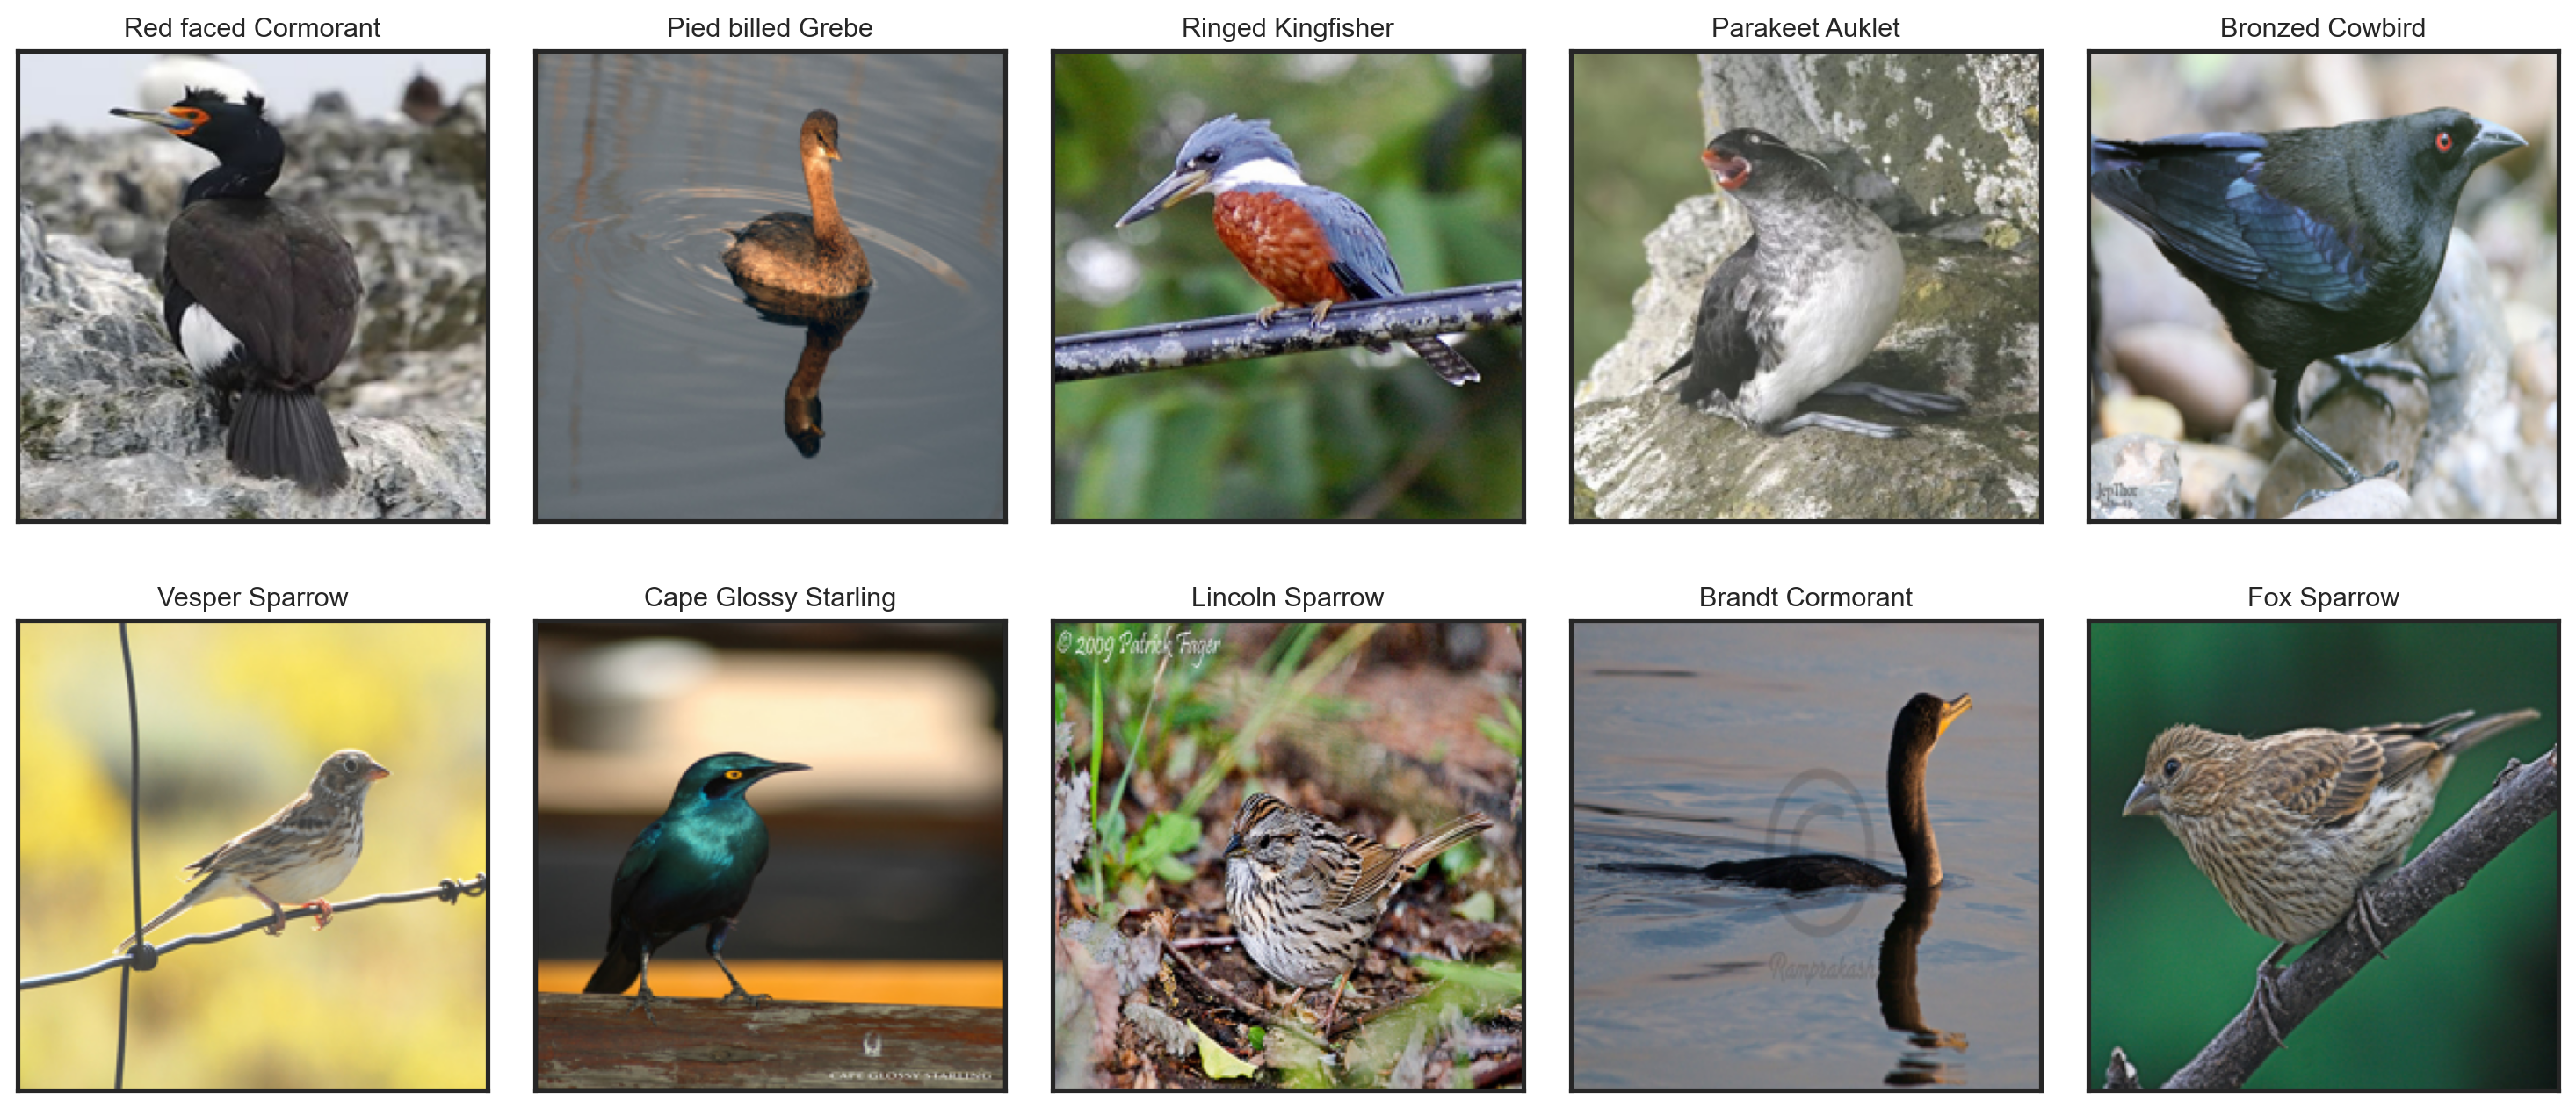

In [45]:
species = classes_df.class_name.str.split('.').str[1].str.replace('_', ' ')

rng = np.random.default_rng(SEED)
picked = rng.choice(nclasses, size=10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
for ax, class_id in zip(axes.flat, picked):
    idx = train_idx[labels[train_idx] == class_id][0]
    ax.imshow(images[idx])
    ax.set(xticks=[], yticks=[], title=species[class_id])
    ax.title.set_fontsize(11)
fig.tight_layout()

# The backbone

We use [EfficientNetV2S](https://keras.io/api/applications/efficientnet_v2/) ([Tan & Le 2021](https://arxiv.org/abs/2104.00298)), pretrained on ImageNet. Three arguments matter:

- `weights='imagenet'` — load the pretrained weights rather than random ones. This is the whole point.
- `include_top=False` — drop the original 1000-way ImageNet classifier. We want the features, not ImageNet's predictions.
- `pooling='avg'` — the convolutional stack outputs a 7x7x1280 feature map; global average pooling collapses the spatial dimensions and gives us a single **1280-dimensional vector per image**. That vector is what we will classify.

Setting `backbone.trainable = False` freezes every weight in it.

**About preprocessing:** the other pretrained models in Keras expect you to call `preprocess_input` on the images first. The EfficientNetV2 models do not — normalization is a `Rescaling` layer *inside* the model, and `keras.applications.efficientnet_v2.preprocess_input` is a no-op kept only for API compatibility. This is why we left the images as `uint8` in 0-255. Feeding it already-normalized images in [0, 1] is a silent 255x error and one of the most common ways to get mysteriously bad transfer results.

In [46]:
backbone = keras.applications.EfficientNetV2S(
    weights='imagenet',
    include_top=False,
    pooling='avg',
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
)
backbone.trainable = False

embedding_dim = backbone.output_shape[-1]
print('{:,} parameters in the backbone, all frozen'.format(backbone.count_params()))
print('{} layers, embedding dimension {}'.format(len(backbone.layers), embedding_dim))
print('First two layers:', [layer.name for layer in backbone.layers[:2]])

20,331,360 parameters in the backbone, all frozen
514 layers, embedding dimension 1280
First two layers: ['input_layer', 'rescaling']


# Protocol A: linear probe

The frozen backbone is a fixed function. That has a useful consequence: we can run it over the dataset **once**, store the 11,788 x 1280 matrix of features, and then train on that matrix instead of on images.

This is a big win. The features are 1280 floats per image, about 60 MB for the whole dataset, versus 1.8 GB of pixels. And training a softmax regression on a 60 MB matrix takes seconds rather than minutes, because we never pay for the 20-million-parameter forward pass again.

It only works because the backbone is frozen. The moment we let its weights change, its output changes every step and there is nothing to cache — which is most of why Protocol B is so much more expensive.

In [9]:
EMBEDDINGS_CACHE = DATA_DIR / 'cub_effnetv2s_embeddings.npy'

if EMBEDDINGS_CACHE.exists():
    Z = np.load(EMBEDDINGS_CACHE)
    print('Loaded cached embeddings', Z.shape)
else:
    t0 = time.time()
    Z = backbone.predict(np.asarray(images), batch_size=64, verbose=0)
    np.save(EMBEDDINGS_CACHE, Z)
    print('Embedded {:,} images in {:.0f}s'.format(len(Z), time.time() - t0), Z.shape)

Z_train = Z[train_idx]
Z_validation = Z[validation_idx]
print('{:.0f} MB of features vs {:.0f} MB of pixels'.format(Z.nbytes / 1e6, images.nbytes / 1e6))

Embedded 11,788 images in 21s (11788, 1280)
60 MB of features vs 1774 MB of pixels


Now the classifier. This is *exactly* the softmax regression model from Day 2 — a single `Dense` layer with a softmax activation, trained with categorical cross-entropy. The only difference is that its input is a 1280-dimensional feature vector rather than raw pixels.

It has `1280 x 200 + 200 = 256,200` parameters, which is a reasonable number of parameters to fit to 5,994 examples. That is the trade we made: we gave up the ability to adapt the features, and in exchange the learning problem became small enough to be well-posed.

We build it with the functional API, since the rest of this notebook needs it too.

In [10]:
def build_probe(seed):
    keras.utils.set_random_seed(seed)
    z = keras.Input(shape=(embedding_dim,), name='embedding')
    yhat = keras.layers.Dense(nclasses, activation='softmax', name='species')(z)
    model = keras.Model(z, yhat, name='linear_probe')
    model.compile(
        loss='categorical_crossentropy',
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        metrics=metrics(),
    )
    return model

build_probe(SEED).summary()

Model: "linear_probe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (InputLayer)          │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ species (Dense)                 │ (None, 200)            │       256,200 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 256,200 (1000.78 KB)

 Trainable params: 256,200 (1000.78 KB)

 Non-trainable params: 0 (0.00 B)

This trains in a few seconds on a GPU, so we run it live.

Trained in 9s


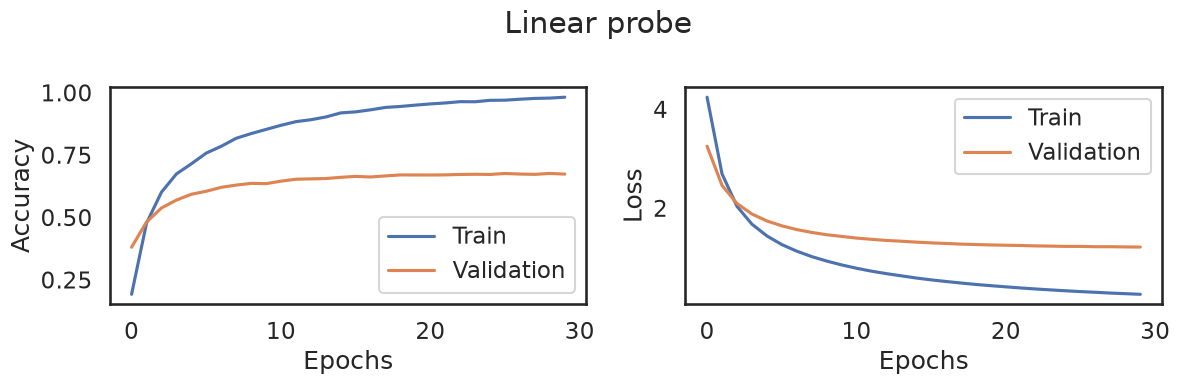

In [11]:
probe = build_probe(SEED)
t0 = time.time()
probe_history = probe.fit(
    x=Z_train, y=Y_train, batch_size=128, epochs=30,
    validation_data=(Z_validation, Y_validation), verbose=0,
).history
print('Trained in {:.0f}s'.format(time.time() - t0))
plot_history(probe_history, title='Linear probe')

The training accuracy keeps climbing while the validation accuracy flattens out — the probe overfits too, even with only 256,200 parameters. But it flattens at a useful level, not at chance (chance here is 0.5%).

Let's score it. We report **top-1** accuracy, the fraction of images whose predicted species is correct, and **top-5** accuracy, the fraction where the correct species is among the five most likely. On a 200-way fine-grained problem top-5 is the more forgiving and often the more informative number: it tells us whether the model is confused between similar species or genuinely lost.

In [12]:
probe_score = probe.evaluate(Z_validation, Y_validation, verbose=0, return_dict=True)
print('Linear probe: top-1 {accuracy:.2%}, top-5 {top5_accuracy:.2%}'.format(**probe_score))

Linear probe: top-1 67.36%, top-5 91.03%


## Run-to-run variance

A single number here would be misleading. Nothing about the backbone is random any more, but the head initialization and the order of the mini-batches still are, and on a 200-class problem with 30 images per class that moves the result by a few tenths of a percent.

So we train the probe again with a different seed and report a range. This costs seconds, and it tells us how big a difference has to be before it means anything.

In [13]:
SEEDS = (SEED, SEED + 1)
probes, probe_scores = {}, {}

for seed in SEEDS:
    model = build_probe(seed)
    model.fit(x=Z_train, y=Y_train, batch_size=128, epochs=30,
              validation_data=(Z_validation, Y_validation), verbose=0)
    probes[seed] = model
    probe_scores[seed] = model.evaluate(Z_validation, Y_validation, verbose=0, return_dict=True)
    print('seed {}: top-1 {accuracy:.2%}, top-5 {top5_accuracy:.2%}'.format(seed, **probe_scores[seed]))

seed 23: top-1 67.36%, top-5 91.03%


seed 24: top-1 67.88%, top-5 90.94%


Save the probe and its history, so this half of the notebook can be reloaded without recomputing anything.

In [14]:
probes[SEED].save('../data/cub_effnetv2s_probe.keras')
with open('../data/cub_effnetv2s_probe_history.p', 'wb') as f:
    pickle.dump(probe_history, f)

In [15]:
probe = keras.models.load_model('../data/cub_effnetv2s_probe.keras')
with open('../data/cub_effnetv2s_probe_history.p', 'rb') as f:
    probe_history = pickle.load(f)

# Protocol B: fine-tune

Now we let the pretrained weights move. This is where transfer learning gets delicate, because the pretrained features are the valuable thing we were given and a careless optimizer will wreck them in the first few steps. Four decisions protect them.

**1. Unfreeze only the top of the backbone.** The early layers hold the generic edge and texture detectors; those are as useful for birds as for anything else, and there is no information in 6,000 images to improve them. The late layers hold ImageNet-specific object semantics, and *those* are what we want to re-specialize. So we unfreeze the last stage (`block6*`) and the final convolution (`top_*`), and leave the rest frozen. This also cuts the cost of the backward pass.

**2. Keep every batch-norm layer frozen.** A batch-norm layer holds running estimates of the mean and variance of its inputs, computed over 1.2 million ImageNet images. Recomputing those from batches of 32 bird photographs replaces good statistics with noisy ones, and it is a well-known way to make fine-tuning worse. In Keras, setting `trainable = False` on a `BatchNormalization` layer makes it run in inference mode: it uses the stored statistics and does not update them.

**3. A low learning rate with warmup, then cosine decay.** We peak at `1e-4`, a tenth of what the probe used. The first epoch warms up from zero, so the very first gradient steps — the ones taken while the head is still adjusting — are tiny and cannot move the backbone far. After that the rate decays smoothly to zero, which lets the model settle instead of bouncing.

**4. Label smoothing.** Instead of asking for probability 1.0 on the correct species, we ask for 0.9, spread over the rest. On a fine-grained problem where the classes genuinely overlap, demanding total confidence pushes the model to produce large logits and overfit. Note that this changes the loss *value*, so the fine-tune loss curve is not directly comparable to the probe's.

And one more decision, which is a choice about the experiment rather than about the optimizer: we start the head from the **trained probe** rather than from random weights.

In [16]:
def build_finetune(seed, head_weights):
    keras.utils.set_random_seed(seed)
    model_backbone = keras.applications.EfficientNetV2S(
        weights='imagenet', include_top=False, pooling='avg',
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )
    model_backbone.trainable = True
    for layer in model_backbone.layers:
        # only the last stage and the final convolution are adapted
        if not (layer.name.startswith('block6') or layer.name.startswith('top')):
            layer.trainable = False
        # batch-norm statistics come from ImageNet and stay there
        if isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = False

    z = keras.layers.Dropout(rate=0.2)(model_backbone.output)
    yhat = keras.layers.Dense(nclasses, activation='softmax', name='species')(z)
    model = keras.Model(model_backbone.input, yhat, name='finetune')

    # linear-probe-then-fine-tune: the head starts where the probe finished
    model.get_layer('species').set_weights(head_weights)
    return model

def compile_finetune(model, epochs, batch_size):
    steps_per_epoch = int(np.ceil(len(train_idx) / batch_size))
    schedule = keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=0.0,
        decay_steps=steps_per_epoch * epochs,
        warmup_target=1e-4,
        warmup_steps=steps_per_epoch,   # one epoch of warmup
        alpha=0.0,
    )
    model.compile(
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        optimizer=keras.optimizers.Adam(learning_rate=schedule),
        metrics=metrics(),
    )
    return model

EPOCHS = 10
BATCH_SIZE = 32

finetune = compile_finetune(
    build_finetune(SEED, probes[SEED].get_layer('species').get_weights()),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
)
trainable = sum(int(np.prod(w.shape)) for w in finetune.trainable_weights)
print('{:,} trainable of {:,} total parameters ({:.0%})'.format(
    trainable, finetune.count_params(), trainable / finetune.count_params()))

15,048,176 trainable of 20,587,560 total parameters (73%)


Because the head was copied from the probe and the backbone has not moved yet, this model *is* the probe, and evaluating it before training confirms that — the top-1 accuracy matches the probe's, up to the last decimal place (the features are recomputed here rather than read from the cache, so the two paths differ by floating-point noise).

In [17]:
print('Before fine-tuning: top-1 {accuracy:.2%}, top-5 {top5_accuracy:.2%}'.format(
    **finetune.evaluate(X_validation, Y_validation, batch_size=64, verbose=0, return_dict=True)))

Before fine-tuning: top-1 67.35%, top-5 91.03%



This staging has a name. [Kumar et al. 2022](https://arxiv.org/abs/2202.10054) call it **LP-FT**: linear-probe first, then fine-tune. Their argument is that fine-tuning from a randomly initialized head is actively harmful, because the large gradients coming out of a random head in the first few steps are what distort the pretrained features. Training the head first means that by the time the backbone unfreezes, the gradients reaching it are already small and pointing somewhere sensible.

(The loss will *not* match the probe's, because of label smoothing.)

## Training

Unlike the probe, this is a real training run: every step pushes 32 images through 20 million parameters. On an NVIDIA RTX A4000 it takes about 18 seconds per epoch, so 10 epochs per seed and about 6 minutes for the two seeds together. On a CPU it is roughly two orders of magnitude slower and not worth attempting.

In [18]:
finetunes, finetune_scores = {}, {}

for seed in SEEDS:
    model = compile_finetune(
        build_finetune(seed, probes[seed].get_layer('species').get_weights()),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
    )
    print('--- seed', seed, '---')
    t0 = time.time()
    history = model.fit(
        x=X_train, y=Y_train, batch_size=BATCH_SIZE, epochs=EPOCHS,
        validation_data=(X_validation, Y_validation), verbose=2,
    ).history
    finetune_scores[seed] = model.evaluate(X_validation, Y_validation, batch_size=64,
                                           verbose=0, return_dict=True)
    print('seed {}: {:.0f}s, top-1 {accuracy:.2%}, top-5 {top5_accuracy:.2%}'.format(
        seed, time.time() - t0, **finetune_scores[seed]))
    if seed == SEED:
        finetune_history = history
        model.save('../data/cub_effnetv2s_finetune.keras')
        with open('../data/cub_effnetv2s_finetune_history.p', 'wb') as f:
            pickle.dump(history, f)
    del model

--- seed 23 ---


Epoch 1/10


188/188 - 48s - 255ms/step - accuracy: 0.9266 - loss: 1.4646 - top5_accuracy: 0.9943 - val_accuracy: 0.7028 - val_loss: 1.9634 - val_top5_accuracy: 0.9170


Epoch 2/10


188/188 - 14s - 76ms/step - accuracy: 0.9491 - loss: 1.3016 - top5_accuracy: 0.9963 - val_accuracy: 0.7399 - val_loss: 1.8614 - val_top5_accuracy: 0.9256


...

Epoch 9/10


188/188 - 15s - 77ms/step - accuracy: 0.9995 - loss: 0.9937 - top5_accuracy: 1.0000 - val_accuracy: 0.7639 - val_loss: 1.7906 - val_top5_accuracy: 0.9289


Epoch 10/10


188/188 - 15s - 77ms/step - accuracy: 0.9995 - loss: 0.9883 - top5_accuracy: 1.0000 - val_accuracy: 0.7660 - val_loss: 1.7860 - val_top5_accuracy: 0.9279


seed 24: 179s, top-1 76.58%, top-5 92.79%


Load the fine-tuned model and its history. In class, comment out the training cell above and start here.

In [19]:
finetune = keras.models.load_model('../data/cub_effnetv2s_finetune.keras')
with open('../data/cub_effnetv2s_finetune_history.p', 'rb') as f:
    finetune_history = pickle.load(f)

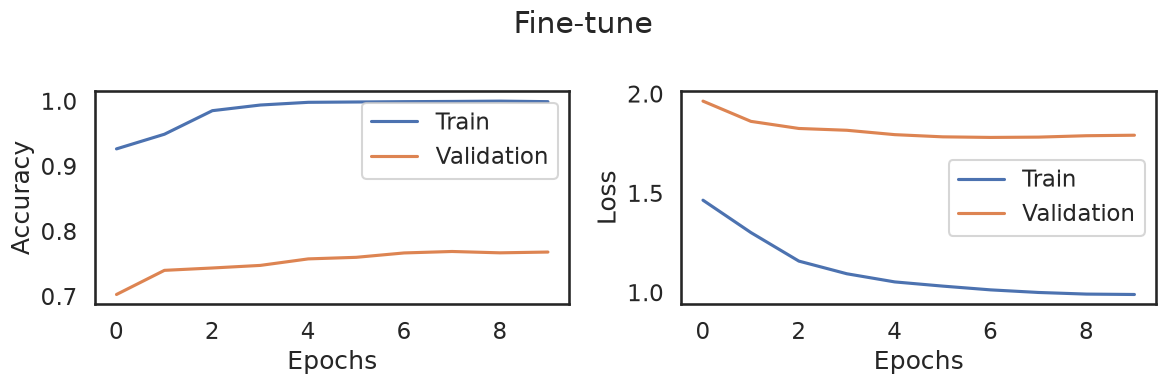

In [20]:
plot_history(finetune_history, title='Fine-tune')

The training accuracy goes to essentially 1.0 within a few epochs — the model memorizes 5,994 images completely. That is exactly the overfitting we predicted at the top of the notebook, and it is happening even though only a quarter of the parameters are trainable.

And yet the validation accuracy keeps improving throughout: the model is simultaneously memorizing the training set *and* generalizing better. The pretrained features are doing the generalizing; the memorization is happening in the part we are adapting, and the low learning rate plus frozen batch-norm is keeping that damage local.

# Comparison

In [21]:
def summarize(scores):
    top1 = [s['accuracy'] for s in scores.values()]
    top5 = [s['top5_accuracy'] for s in scores.values()]
    return {
        'top-1 min': min(top1), 'top-1 max': max(top1),
        'top-5 min': min(top5), 'top-5 max': max(top5),
    }

comparison = pd.DataFrame({
    'Linear probe': summarize(probe_scores),
    'Fine-tune': summarize(finetune_scores),
}).T
print(comparison.to_string(formatters={c: '{:.2%}'.format for c in comparison}))
print()
print('top-1 gain from fine-tuning: {:+.2%} to {:+.2%}'.format(
    comparison.loc['Fine-tune', 'top-1 min'] - comparison.loc['Linear probe', 'top-1 max'],
    comparison.loc['Fine-tune', 'top-1 max'] - comparison.loc['Linear probe', 'top-1 min']))

             top-1 min top-1 max top-5 min top-5 max
Linear probe    67.36%    67.88%    90.94%    91.03%
Fine-tune       76.58%    76.80%    92.79%    92.82%

top-1 gain from fine-tuning: +8.70% to +9.44%


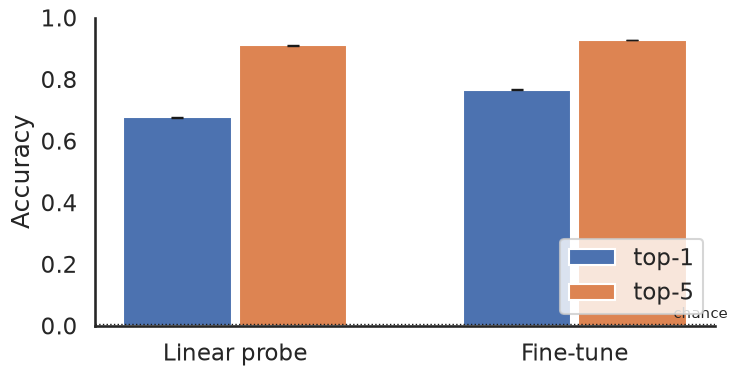

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(2)
for offset, (key, label) in zip((-0.17, 0.17), (('accuracy', 'top-1'), ('top5_accuracy', 'top-5'))):
    values = [[s[key] for s in scores.values()] for scores in (probe_scores, finetune_scores)]
    ax.bar(x + offset, [np.mean(v) for v in values], width=0.32, label=label)
    ax.errorbar(x + offset, [np.mean(v) for v in values],
                yerr=[[np.mean(v) - min(v) for v in values], [max(v) - np.mean(v) for v in values]],
                fmt='none', ecolor='k', capsize=4)
ax.set(xticks=x, xticklabels=['Linear probe', 'Fine-tune'], ylabel='Accuracy', ylim=(0, 1))
ax.axhline(1 / nclasses, ls=':', c='k', lw=1)
ax.text(1.45, 1 / nclasses + 0.02, 'chance', fontsize=11, ha='right')
ax.legend(loc='lower right')
sns.despine()

# Discussion

**Fine-tuning wins here, by about 9% of top-1.** The probe lands near 67% and the fine-tune near 77%, and the seed-to-seed spread is a few tenths of a percent, so a 9% gap is unambiguous. That sits at the top of the range reported in the literature, where fine-tuning typically beats frozen feature extraction on this dataset by 2-10%.

**Both numbers are far above training from scratch.** The 10.9%-versus-57.0% comparison from the introduction is the one number that motivates this entire session. Neither of our protocols is anywhere near it, because both of them start from ImageNet.

**We are below the published state-of-the-art.** Full fine-tunes of ImageNet-pretrained ResNet-50 on CUB reach about 85%, and older backbones land at 73-77%. We get about 77%. The natural suspicion is that we left too much of the backbone frozen — so rather than assume, we measured it, unfreezing progressively more with every other setting held exactly as above:

| unfrozen | trainable parameters | top-1 | top-5 |
|---|---|---|---|
| `top_*` only | 583,880 | 68.62% | 91.11% |
| `block6*` + `top_*` (this notebook) | 15,048,176 | 76.80% | 92.82% |
| `block5*` onward | 18,475,344 | 78.60% | 93.34% |
| `block4*` onward | 19,380,224 | 78.84% | 93.44% |
| everything | 20,279,816 | 79.60% | 93.77% |

Unfreezing the *entire* backbone is worth **2.8%** over our choice, and most of that arrives with `block5`, after which it flattens. 
A horizontal flip augmentation is worth another 0.4%. Together those leave us about 5% short of 85%, so the gap is **not** mainly about how much of the backbone we unfroze. The remaining candidates — input resolution (we run at 224x224; EfficientNetV2S was designed for 384x384, and published CUB numbers often use larger crops still), a schedule longer than 10 epochs, and the heavier augmentation recipes used in the literature — we have *not* measured, so we do not claim them.

Two things are worth reading off that table. 
1. Unfreezing only `top_*` barely beats the frozen probe, 68.62% against 67.36%: the final 1x1 1. Uwn has almost nothing to contribute, and the gains come from adapting the feature blocks underneath it. 
2. The return on trainable parameters is steeply diminishing — our `block6*` choice buys three quarters of the total available gain, and the last 5 million parameters buy 0.8% for a third more training time per epoch.

**Caveat:** this task is unusually friendly to ImageNet. 59 of ImageNet's 1000 classes are bird categories, and they overlap CUB. The backbone has not merely learned generic textures that happen to be useful for birds — it has been explicitly trained to tell birds apart. That is *why* the transfer is this good, and it means these numbers are an optimistic picture of what transfer learning gives you. A task genuinely far from ImageNet — medical imaging, satellite imagery, individual-animal re-identification, the mel-spectrograms in the [audio session](audio.ipynb) — will look worse.

**Probe versus fine-tune is not a settled question.** It is tempting to read our result as "fine-tuning is simply better." Kumar et al. 2022 show that this depends entirely on what you are measuring. Fine-tuning beats a linear probe *in distribution* by around 2%, but **loses to it out of distribution by around 7%**, because fine-tuning distorts the pretrained features and those distorted features generalize worse under a large shift.
A frozen backbone cannot be distorted, which is precisely its advantage. Our validation set is drawn from the same distribution as our training set, so this experiment can only see the case where fine-tuning wins.

Their recommended fix is the LP-FT staging we used: train the head first, then unfreeze. So the freeze-then-unfreeze structure of this notebook is not just a convenient way to organize a lesson — it is the current recommendation.

**When to use which, in practice:**

- **Linear probe** when you have very little data, very little compute, need a baseline in minutes, or expect distribution shift at deployment. It is also the right diagnostic: if the probe already does well, your task is close to the pretraining task, and if it does badly, no amount of fine-tuning will rescue you.
- **Fine-tune** when you have enough data to support it, your deployment distribution matches your training distribution, and the extra few points matter. Always stage it: probe first, then unfreeze the top, low learning rate, batch-norm frozen.


# Exercises

1. **Why does unfreezing more saturate?** The table in the discussion shows validation accuracy flattening once `block5*` is unfrozen, even though each further step adds millions of trainable parameters. Reproduce one or two of those rows, then account for the shape of the curve. What would you expect to change if we had 60,000 training images instead of 6,000?
2. **Close the gap to the published numbers.** The discussion names three levers we did *not* measure: input resolution, schedule length, and augmentation. Pick one, measure it, and report what it is worth. Resolution is the cheapest to try — rebuild the backbone with `input_shape=(384, 384, 3)` and re-decode the images at that size.
3. **Does the batch-norm rule matter?** Remove the `isinstance(layer, keras.layers.BatchNormalization)` branch from `build_finetune` so the batch-norm layers update their statistics, and re-run. Predict the direction of the change before you run it.
4. **Break the preprocessing on purpose.** Divide the images by 255 before embedding them and re-run the linear probe. How far does the accuracy fall? This is the failure mode the notebook warned about, and it is useful to know what it looks like.
5. **Where does the model actually fail?** Build the 200x200 confusion matrix for the fine-tuned model and find the most-confused pairs of species. Are they the pairs a birdwatcher would also find hard?
6. **A harder transfer.** Repeat the two protocols on a dataset further from ImageNet and compare the probe-versus-fine-tune gap to the one measured here.



# References

- Wah, Branson, Welinder, Perona & Belongie 2011, [The Caltech-UCSD Birds-200-2011 Dataset](https://www.vision.caltech.edu/datasets/cub_200_2011/), CNS-TR-2011-001.
- Branson, Van Horn, Belongie & Perona 2014, [Bird Species Categorization Using Pose Normalized Deep Convolutional Nets](https://arxiv.org/abs/1406.2952) - the source of the 10.9% versus 57.0% from-scratch comparison.
- Kumar, Raghunathan, Jones, Ma & Liang 2022, [Fine-Tuning can Distort Pretrained Features and Underperform Out-of-Distribution](https://arxiv.org/abs/2202.10054), ICLR - the LP-FT paper.
- Tan & Le 2021, [EfficientNetV2: Smaller Models and Faster Training](https://arxiv.org/abs/2104.00298), ICML.
- Yosinski, Clune, Bengio & Lipson 2014, [How transferable are features in deep neural networks?](https://arxiv.org/abs/1411.1792), NeurIPS - the layer-by-layer study of what transfers.
- [Keras transfer learning and fine-tuning guide](https://keras.io/guides/transfer_learning/).
- [Keras Applications](https://keras.io/api/applications/) - the catalogue of pretrained backbones.
- [Transfer learning homework](../exercises/transfer_learning.ipynb) applies the same idea to Fashion-MNIST.

# Colophon
This notebook was written by [Yoav Ram](http://python.yoavram.com).

This work is licensed under a CC BY-NC-SA 4.0 International License.

![Python logo](https://www.python.org/static/community_logos/python-logo.png)